In [7]:
# Import thư viện cần thiết
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, BatchNormalization
import matplotlib.pyplot as plt

# Đường dẫn thư mục chứa dữ liệu
paths = [
    r"Viet Nam Stock Market Data"
]

# Tên các file CSV
files = ["HOSEVNINDEXM30.csv", "HOSEVN100M30.csv", "HOSEVN30M30.csv"]

# Hàm tìm file trong các đường dẫn
def find_file(file_name, search_paths):
    for path in search_paths:
        full_path = os.path.join(path, file_name)
        if os.path.exists(full_path):
            return full_path
    return None

# Load các dataset
datasets = {}
for file in files:
    file_path = find_file(file, paths)
    if file_path:
        datasets[file] = pd.read_csv(file_path)
        print(f"{file} loaded successfully with shape {datasets[file].shape}")
    else:
        print(f"{file} not found in the given paths.")

# Kiểm tra dữ liệu đầu tiên
for name, df in datasets.items():
    print(f"\n{name} head:")
    display(df.head())


HOSEVNINDEXM30.csv loaded successfully with shape (22164, 9)
HOSEVN100M30.csv loaded successfully with shape (22158, 9)
HOSEVN30M30.csv loaded successfully with shape (21977, 9)

HOSEVNINDEXM30.csv head:


,time,open,high,low,close,55EMA,89EMA,200EMA,Plot
0,1451872800,579.03,579.46,578.33,579.28,NaN,NaN,NaN,NaN
1,1451874600,579.48,579.97,578.99,579.67,NaN,NaN,NaN,NaN
2,1451876400,579.55,579.55,578.14,578.52,NaN,NaN,NaN,NaN
3,1451878200,579.34,579.34,577.76,577.94,NaN,NaN,NaN,NaN
4,1451880000,577.84,579.32,577.44,579.32,NaN,NaN,NaN,NaN



HOSEVN100M30.csv head:


,time,open,high,low,close,55EMA,89EMA,200EMA,Plot
0,1451872800,573.52,573.52,571.10,572.00,NaN,NaN,NaN,NaN
1,1451874600,572.41,573.14,571.89,572.89,NaN,NaN,NaN,NaN
2,1451876400,572.61,572.61,571.20,571.42,NaN,NaN,NaN,NaN
3,1451878200,572.30,572.52,571.00,571.23,NaN,NaN,NaN,NaN
4,1451880000,571.22,572.72,570.69,572.72,NaN,NaN,NaN,NaN



HOSEVN30M30.csv head:


,time,open,high,low,close,55EMA,89EMA,200EMA,Plot
0,1451872800,595.57,595.57,592.70,593.48,NaN,NaN,NaN,NaN
1,1451874600,594.01,594.68,593.38,594.33,NaN,NaN,NaN,NaN
2,1451876400,594.01,594.01,592.39,592.83,NaN,NaN,NaN,NaN
3,1451878200,593.80,594.20,592.27,592.60,NaN,NaN,NaN,NaN
4,1451880000,592.52,594.08,591.83,594.08,NaN,NaN,NaN,NaN


In [23]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ===== Lấy close từ 3 file =====
close_cols = []
for file in files:
    df = datasets[file]
    close_cols.append(df['close'].reset_index(drop=True))

data = pd.concat(close_cols, axis=1)
data.columns = ['close1', 'close2', 'close3']
data = data.dropna()

# ===== Tính log-return =====
log_returns = np.log(data / data.shift(1)).dropna()

# ===== Scale log-return =====
scaler = StandardScaler()
logret_scaled = scaler.fit_transform(log_returns.values)

# ===== Tạo sequence =====
def create_sequences(data, look_back=10):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back, :])
        y.append(data[i+look_back, 0])  # log-return close1
    return np.array(X), np.array(y)

look_back = 10
X, y = create_sequences(logret_scaled, look_back)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(X_train.shape, y_train.shape)


(17572, 10, 3) (17572,)


C:\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                       │ (None, 10, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_14 (LSTM)                       │ (None, 10, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 10, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_16 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,905 (374.63 KB)

 Trainable params: 95,905 (374.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 1.1006 - val_loss: 0.5937
Epoch 2/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 1.0951 - val_loss: 0.5981
Epoch 3/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 1.0935 - val_loss: 0.5926
Epoch 4/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 1.0918 - val_loss: 0.6009
Epoch 5/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 1.0923 - val_loss: 0.5922
Epoch 6/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - loss: 1.0869 - val_loss: 0.5932
Epoch 7/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 1.0914 - val_loss: 0.5943
Epoch 8/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 1.0868 - val_loss: 0.5969
Epoch 9/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 1.0823 - val_loss: 0.5955
Epoch 10/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 1.0839 - val_loss: 0.6026
Epoch 11/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 1.0783 - val_loss: 0.5985
Epoch 12/30
550/550 ━━━━━━━━━━━

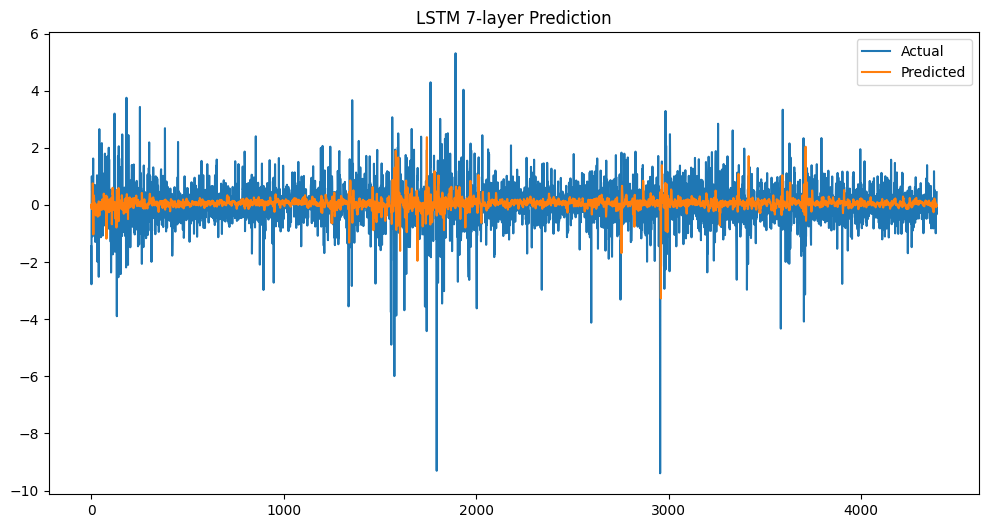

In [24]:
# LSTM 7 layers
model_lstm_7 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(look_back, 3)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dense(1)
])

model_lstm_7.compile(
    optimizer='adam',
    loss='mse'
)

model_lstm_7.summary()

# Train
history_lstm = model_lstm_7.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Predict
y_pred_lstm = model_lstm_7.predict(X_test).reshape(-1)

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_lstm, label='Predicted')
plt.title('LSTM 7-layer Prediction')
plt.legend()
plt.show()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)             │ (None, 10, 64)              │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_5 (SimpleRNN)             │ (None, 10, 64)              │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_6 (SimpleRNN)             │ (None, 10, 64)              │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_7 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,001 (93.75 KB)

 Trainable params: 24,001 (93.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 1.2005 - val_loss: 0.6354
Epoch 2/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 1.1216 - val_loss: 0.5944
Epoch 3/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 1.1065 - val_loss: 0.5960
Epoch 4/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 1.0971 - val_loss: 0.6036
Epoch 5/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 1.0998 - val_loss: 0.6009
Epoch 6/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 1.0986 - val_loss: 0.5933
Epoch 7/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 1.1074 - val_loss: 0.5944
Epoch 8/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 1.1057 - val_loss: 0.6150
Epoch 9/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.1061 - val_loss: 0.5950
Epoch 10/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 1.1057 - val_loss: 0.5923
Epoch 11/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.1053 - val_loss: 0.5956
Epoch 12/30
550/550 ━━━━━━━━━━━━━━

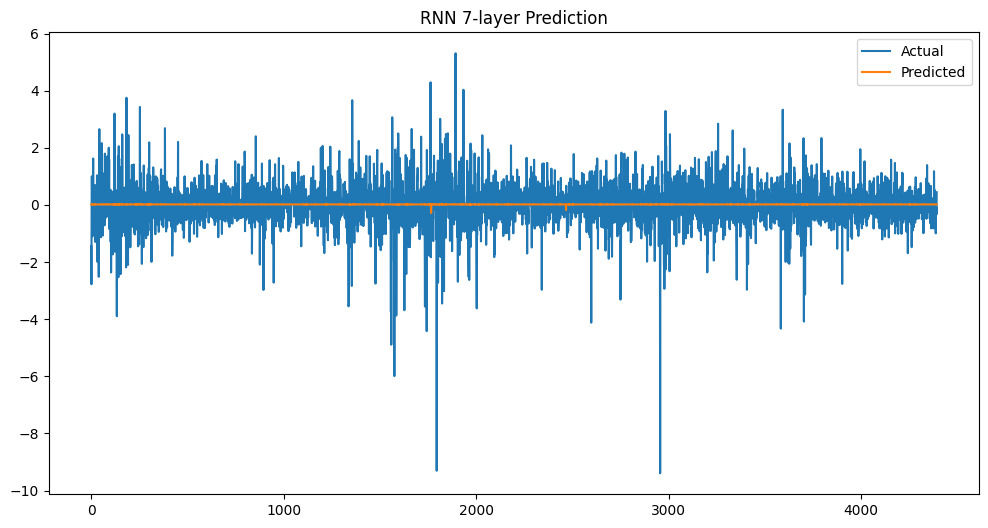

In [25]:
# RNN 7 layers
model_rnn_7 = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(look_back, 3)),
    Dropout(0.2),

    SimpleRNN(64, return_sequences=True),
    Dropout(0.2),

    SimpleRNN(64, return_sequences=True),
    Dropout(0.2),

    SimpleRNN(32, return_sequences=False),
    Dense(1)
])

model_rnn_7.compile(
    optimizer='adam',
    loss='mse'
)

model_rnn_7.summary()

# Train
history_rnn = model_rnn_7.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Predict
y_pred_rnn = model_rnn_7.predict(X_test).reshape(-1)

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_rnn, label='Predicted')
plt.title('RNN 7-layer Prediction')
plt.legend()
plt.show()


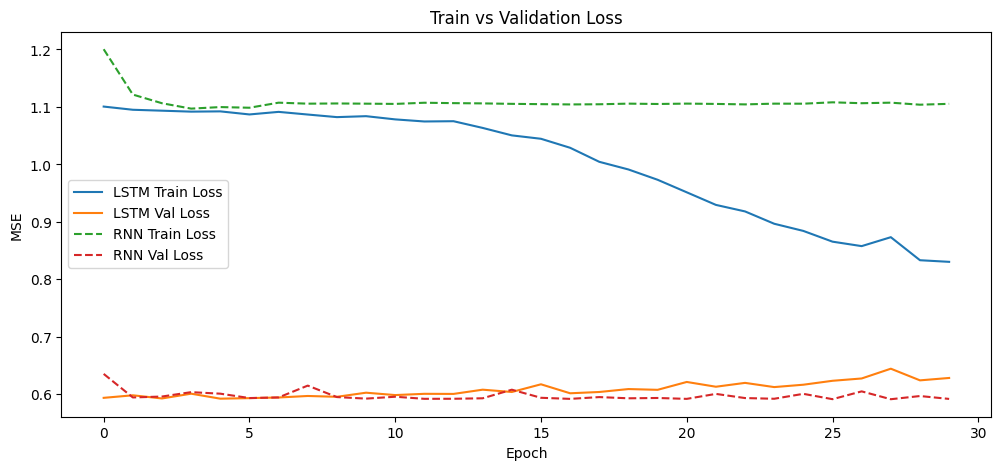

In [26]:
# LOSS TRAIN vs VALIDATION
plt.figure(figsize=(12,5))

plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')

plt.plot(history_rnn.history['loss'], linestyle='--', label='RNN Train Loss')
plt.plot(history_rnn.history['val_loss'], linestyle='--', label='RNN Val Loss')

plt.title('Train vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


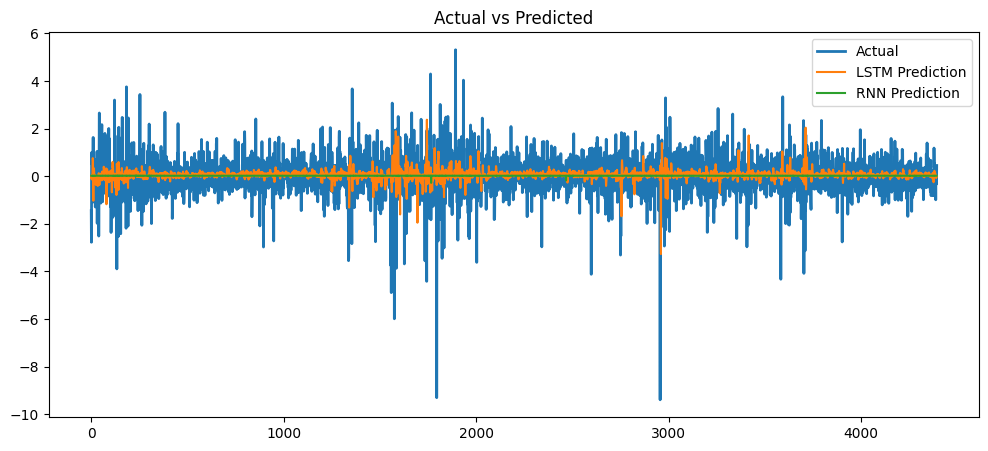

In [27]:
# ACTUAL vs PREDICTED
plt.figure(figsize=(12,5))
plt.plot(y_test, label='Actual', linewidth=2)
plt.plot(y_pred_lstm, label='LSTM Prediction')
plt.plot(y_pred_rnn, label='RNN Prediction')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()


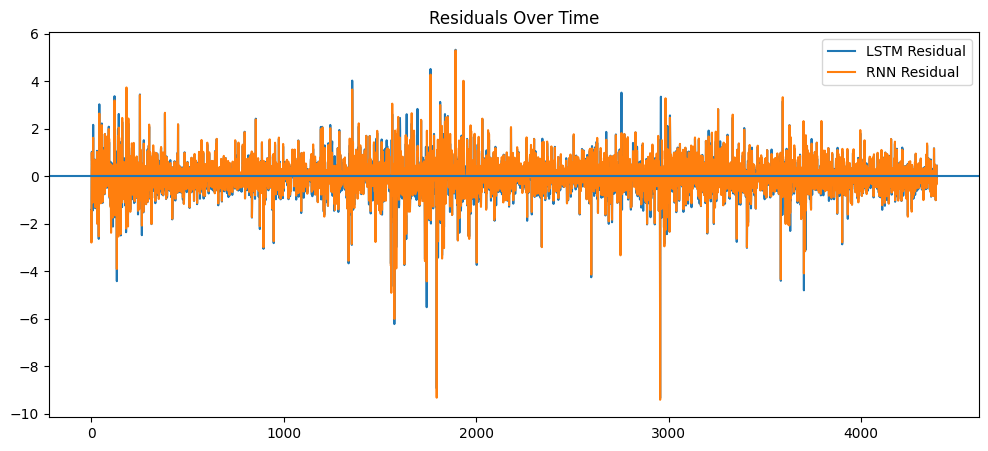

In [28]:
# RESIDUAL PLOT
res_lstm = y_test - y_pred_lstm
res_rnn  = y_test - y_pred_rnn

plt.figure(figsize=(12,5))
plt.plot(res_lstm, label='LSTM Residual')
plt.plot(res_rnn, label='RNN Residual')
plt.axhline(0)
plt.title('Residuals Over Time')
plt.legend()
plt.show()


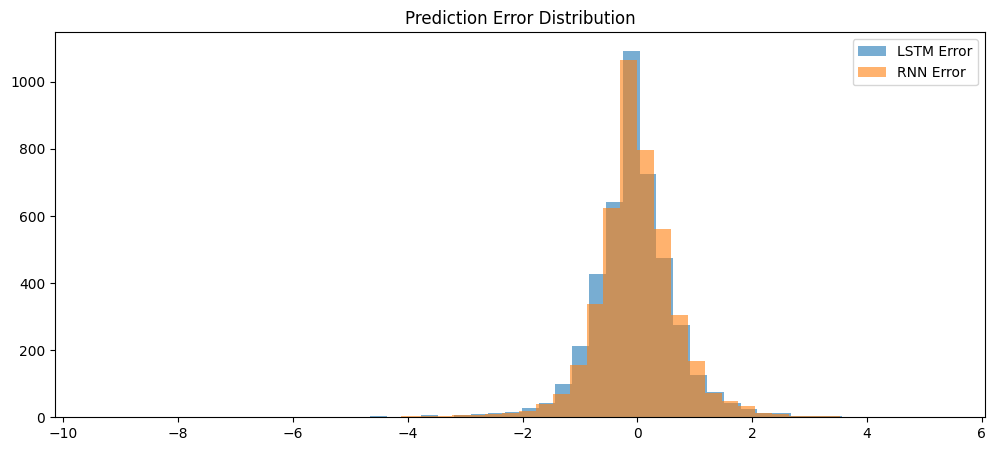

In [29]:
# ERROR DISTRIBUTION
plt.figure(figsize=(12,5))
plt.hist(res_lstm, bins=50, alpha=0.6, label='LSTM Error')
plt.hist(res_rnn, bins=50, alpha=0.6, label='RNN Error')
plt.title('Prediction Error Distribution')
plt.legend()
plt.show()


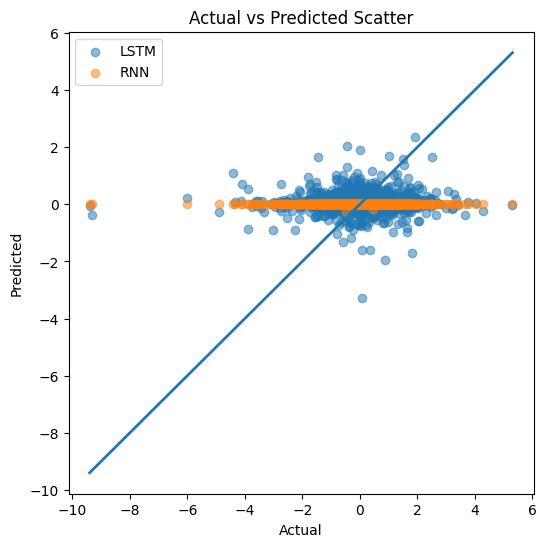

In [30]:
# SCATTER: ACTUAL vs PREDICTED
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lstm, alpha=0.5, label='LSTM')
plt.scatter(y_test, y_pred_rnn, alpha=0.5, label='RNN')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Scatter')
plt.legend()
plt.show()


In [31]:
# Đánh giá định lượng
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} -> MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}")
    return rmse

rmse_lstm = evaluate_model(y_test, y_pred_lstm, "LSTM")
rmse_rnn  = evaluate_model(y_test, y_pred_rnn,  "RNN")


LSTM -> MSE: 0.628290, RMSE: 0.792647, MAE: 0.530182
RNN -> MSE: 0.591818, RMSE: 0.769297, MAE: 0.509031


In [32]:
# Chọn mô hình
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
rmse_rnn  = np.sqrt(mean_squared_error(y_test, y_pred_rnn))

best_model = model_lstm_7 if rmse_lstm < rmse_rnn else model_rnn_7
print("Best model:", "LSTM" if rmse_lstm < rmse_rnn else "RNN")


Best model: RNN


In [33]:
# Hàm dự báo
def forecast_log_return(model, last_seq, steps):
    seq = last_seq.copy()
    preds = []

    for _ in range(steps):
        pred = model.predict(seq.reshape(1, look_back, 3), verbose=0)[0,0]
        preds.append(pred)

        new_step = seq[-1].copy()
        new_step[0] = pred
        seq = np.vstack([seq[1:], new_step])

    return np.array(preds)

# CHUYỂN LOG-RETURN → GIÁ THẬT
def logreturn_to_price(last_price, log_returns):
    prices = [last_price]
    for r in log_returns:
        prices.append(prices[-1] * np.exp(r))
    return np.array(prices[1:])


In [34]:
last_seq = X_test[-1]
last_real_price = data['close1'].iloc[-1]

# số bước
steps_day = 1
steps_month = 22
steps_year = 252

logret_day   = forecast_log_return(best_model, last_seq, steps_day)
logret_month = forecast_log_return(best_model, last_seq, steps_month)
logret_year  = forecast_log_return(best_model, last_seq, steps_year)

price_day   = logreturn_to_price(last_real_price, logret_day)
price_month = logreturn_to_price(last_real_price, logret_month)
price_year  = logreturn_to_price(last_real_price, logret_year)

print("Forecast 1 day ahead:", price_day[-1])
print("Forecast 1 month ahead:", price_month[-1])
print("Forecast 1 year ahead:", price_year[-1])


Forecast 1 day ahead: 1267.5729202616214
Forecast 1 month ahead: 1821.95863301619
Forecast 1 year ahead: 105150.64635934048
